# HANK-SAM Tutorial: General Equilibrium Analysis of Fiscal Policy

**Authors**: Christopher D. Carroll and William Du, based on Carroll, Crawley, Du, Frankovic, and Tretvoll (2025)

📄 **Paper**: [[Welfare and Spending Effects of Consumption Stimulus Policies](https://llorracc.github.io/HAFiscal-Public/#x1-10001)]

---

## Overview

This tutorial demonstrates the **HANK-SAM** (Heterogeneous Agent New Keynesian - Sequence Space Jacobian) model from [Section 5](https://llorracc.github.io/HAFiscal-Public/#x1-340005) of the paper.

The main paper analyzes fiscal stimulus in **partial equilibrium** ([Section 4](https://llorracc.github.io/HAFiscal-Public/#x1-250004)). This tutorial shows how results change when we add **general equilibrium effects**—monetary policy response, wage/price adjustments, and labor market dynamics.

### What This Tutorial Shows

We analyze how general equilibrium effects change fiscal multipliers for three policies:

1. **UI Extensions** — [Section 4.1.2](https://llorracc.github.io/HAFiscal-Public/#x1-280004.1.2) — Extending unemployment benefits
2. **Stimulus Checks** — [Section 4.1.1](https://llorracc.github.io/HAFiscal-Public/#x1-270004.1.1) — Direct transfers to households  
3. **Tax Cuts** — [Section 4.1.3](https://llorracc.github.io/HAFiscal-Public/#x1-290004.1.3) — Temporary reduction in wage taxation

### Key Research Question

> Does adding general equilibrium feedback change the relative effectiveness of fiscal policies?

**Answer** (from [Section 5](https://llorracc.github.io/HAFiscal-Public/#x1-340005)): The ranking of policies is preserved, because the intertemporal dynamics of consumption in the HANK model are similar to the dynamics in the simpler model.

### Model Components

The HANK-SAM model ([Appendix A](https://llorracc.github.io/HAFiscal-Public/#x1-37000A)) combines:

| Component | Description | Paper Reference |
|-----------|-------------|-----------------|
| **Household Block** | Pre-computed Jacobians from HA-Fiscal model | [Section 2](https://llorracc.github.io/HAFiscal-Public/#x1-70002) |
| **Labor Market** | Search-and-matching with endogenous unemployment | [Appendix A](https://llorracc.github.io/HAFiscal-Public/#x1-37000A) |
| **Monetary Policy** | Taylor rule (or fixed rate alternatives) | [Section 5](https://llorracc.github.io/HAFiscal-Public/#x1-340005) |
| **Fiscal Policy** | Government budget with debt feedback | [Section 2.2](https://llorracc.github.io/HAFiscal-Public/#x1-90002.2) |

### Monetary Policy Scenarios

We compare three monetary regimes (see [Section 5](https://llorracc.github.io/HAFiscal-Public/#x1-340005) for discussion):

- **Standard Taylor Rule**: Fed responds to inflation/output (φπ=1.5, φy=0.125)
- **Fixed Nominal Rate**: Zero lower bound scenario
- **Fixed Real Rate**: Alternative for robustness

### Connection to Main Results

| Analysis | Paper Section | Key Tables/Figures |
|----------|---------------|-------------------|
| Partial equilibrium multipliers | [Section 4.2](https://llorracc.github.io/HAFiscal-Public/#x1-300004.2) | Table 6 |
| Welfare comparison | [Section 4.3](https://llorracc.github.io/HAFiscal-Public/#x1-310004.3) | Table 7 |
| HANK-SAM robustness | [Section 5](https://llorracc.github.io/HAFiscal-Public/#x1-340005) | Figure 5 |

---

## Notebook Structure

1. **Setup**: Calibration ([Section 3](https://llorracc.github.io/HAFiscal-Public/#x1-170003)) and model specification
2. **Policy Experiments**: UI, transfers, tax cuts ([Section 4](https://llorracc.github.io/HAFiscal-Public/#x1-250004))
3. **Results**: Multipliers and consumption responses
4. **Interpretation**: Comparison to partial equilibrium results

Let's begin!


In [1]:
# Import necessary libraries
import numpy as np
from copy import deepcopy
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Import utilities (plotting + calibration loading)
from HANK_and_SAM_tutorial_utils import (
    load_calibration,
    get_flat_calibration,
    plot_multipliers_three_experiments,
    plot_consumption_irfs_three_experiments,
    plot_consumption_irfs_three,
    plot_consumption_irf,
    plot_consumption_multipliers,
)

# Load calibration from JSON (auto-generated by HA-Fiscal-HANK-SAM.py)
cal = load_calibration()
print(f"Loaded calibration from: Code/HA-Models/FromPandemicCode/HA_Fiscal_calibration.json")

Loaded calibration from: Code/HA-Models/FromPandemicCode/HA_Fiscal_calibration.json


---

## Part 1: Model Setup

### Labor Market Calibration

The HANK-SAM model includes a **search-and-matching labor market** ([Appendix A](https://llorracc.github.io/HAFiscal-Public/#x1-37000A)):

- Job finding probability: 2/3 per quarter (matches U.S. data)
- Steady-state unemployment rate: ~3%
- Endogenous job separation

These parameters govern how unemployment responds to fiscal shocks. See [Section 3.3.1](https://llorracc.github.io/HAFiscal-Public/#x1-210003.3.1) for the full calibration.


In [2]:
# Labor market parameters from calibration
job_find = cal['labor_market']['job_find']
EU_prob = cal['labor_market']['EU_prob']
job_sep = cal['labor_market']['job_sep']
ss_dstn = cal['labor_market']['ss_dstn']
N_ss = cal['labor_market']['N_ss']
U_ss = cal['labor_market']['U_ss']

num_mrkv = len(ss_dstn)

# Reconstruct Markov transition matrix from calibration
markov_array_ss = np.array([
    [1 - job_sep * (1 - job_find), job_find, job_find, job_find, job_find, job_find],
    [job_sep * (1 - job_find), 0.0, 0.0, 0, 0, 0],
    [0.0, (1 - job_find), 0.0, 0.0, 0.0, 0.0],
    [0.0, 0, (1 - job_find), 0.0, 0.0, 0.0],
    [0.0, 0, 0.0, (1 - job_find), 0.0, 0.0],
    [0.0, 0.0, 0, 0, (1 - job_find), (1 - job_find)],
])

mrkv_temp_for_will = markov_array_ss

print(f"Labor market: job_find={job_find:.4f}, N_ss={N_ss:.4f}, U_ss={U_ss:.4f}")

Labor market: job_find=0.6667, N_ss=0.9693, U_ss=0.0307


### Unemployment Jacobians

We need to compute how unemployment responds to changes in job-finding rates.
This captures the **labor market dynamics** of fiscal policy.


In [3]:
# jacobians for unemployment rate


def create_matrix_U(dx):
    job_find_dx = job_find + dx

    markov_array = np.array(
        [
            [
                1 - job_sep * (1 - job_find_dx),
                job_find_dx,
                job_find_dx,
                job_find_dx,
                job_find_dx,
                job_find_dx,
            ],
            [job_sep * (1 - job_find_dx), 0.0, 0.0, 0, 0, 0],
            [0.0, (1 - job_find_dx), 0.0, 0.0, 0.0, 0.0],
            [0.0, 0, (1 - job_find_dx), 0.0, 0.0, 0.0],
            [0.0, 0, 0.0, (1 - job_find_dx), 0.0, 0.0],
            [0.0, 0.0, 0, 0, (1 - job_find_dx), (1 - job_find_dx)],
        ]
    )

    return markov_array


dx = 0.0001


dstn = ss_dstn

bigT = 300  # dimension of jacobian matrix, bigT x bigT
UJAC = np.zeros((num_mrkv, bigT, bigT))

for s in range(bigT):
    for i in range(bigT):
        if i == s:
            tranmat = create_matrix_U(dx)

            dstn = np.dot(tranmat, dstn)

        else:
            dstn = np.dot(mrkv_temp_for_will, dstn)

        UJAC[:, i, s] = (dstn - ss_dstn) / dx

### General Equilibrium Parameters

These parameters govern:
- **Vacancy posting** and matching efficiency
- **Government consumption** and fiscal rules
- **Wage/price stickiness** (Phillips curve)

Most values are standard in the HANK literature.


In [4]:
# GE parameters from calibration
alpha = cal['matching']['alpha']
phi_ss = cal['matching']['phi_ss']
v_ss = cal['matching']['v_ss']
theta_ss = cal['matching']['theta_ss']
chi_ss = cal['matching']['chi_ss']
eta_ss = cal['matching']['eta_ss']

R = cal['household']['R']
r_ss = cal['household']['r_ss']
C_ss_sim = cal['household']['C_ss']
C_ss = C_ss_sim
A_ss_sim = cal['household']['A_ss']
A_ss = A_ss_sim

delta = cal['bonds']['delta']
qb_ss = cal['bonds']['qb_ss']
B_ss = cal['bonds']['B_ss']

wage_ss = cal['wages_taxes']['wage_ss']
tau_ss = cal['wages_taxes']['tau_ss']
inc_ui_exhaust = cal['wages_taxes']['inc_ui_exhaust']
UI = cal['wages_taxes']['UI']

G_ss = cal['government']['G_ss']
Y_priv = cal['government']['Y_priv']

kappa = cal['firms']['kappa']
HC_ss = cal['firms']['HC_ss']
epsilon_p = cal['firms']['epsilon_p']
MC_ss = cal['firms']['MC_ss']
Z_ss = cal['firms']['Z_ss']
Y_ss = cal['firms']['Y_ss']

pi_ss = cal['inflation']['pi_ss']
varphi = cal['inflation']['varphi']

print(f"Loaded GE calibration: C_ss={C_ss:.4f}, Y_ss={Y_ss:.4f}, R={R}")

Loaded GE calibration: C_ss=0.6910, Y_ss=1.2438, R=1.01


# Parameters to be tuned in dashboard

In [5]:
# Policy parameters (from calibration defaults, can be overridden)
phi_pi = cal['policy_defaults']['phi_pi']
phi_y = cal['policy_defaults']['phi_y']
rho_r = cal['policy_defaults']['rho_r']
phi_b = cal['policy_defaults']['phi_b']
phi_w = cal['policy_defaults']['phi_w']
real_wage_rigidity = cal['policy_defaults'].get('real_wage_rigidity', 0.837)

kappa_p_ss = cal['inflation']['kappa_p_ss']
print("slope of phillips curve", kappa_p_ss)

# Fiscal policy experiment parameters
UI_extension_length = cal.get('fiscal_experiments', {}).get('UI_extension_length', 4)
stimulus_check_length = cal.get('fiscal_experiments', {}).get('stimulus_check_length', 1)
tax_cut_length = cal.get('fiscal_experiments', {}).get('tax_cut_length', 8)

# Computation parameters
bigT = cal['computation']['bigT']

print(f"Policy: phi_pi={phi_pi}, phi_b={phi_b}, bigT={bigT}")

slope of phillips curve 0.06191950464396284
Policy: phi_pi=1.5, phi_b=0.015, bigT=300


# Specify General Equilibrium Blocks

In [6]:
import sequence_jacobian as sj
from sequence_jacobian.classes import JacobianDict, SteadyStateDict
from sequence_jacobian import create_model  # functions


@sj.simple
def unemployment1(U1, U2, U3, U4, U5):
    U = U1 + U2 + U3 + U4 + U5

    return U


@sj.simple
def marginal_cost(HC, Z):
    MC = HC / Z
    return MC


@sj.solved(unknowns={"HC": (-10, 10.0)}, targets=["HC_resid"], solver="brentq")
def hiring_cost(HC, Z, phi, job_sep, r_ante, w):
    HC_resid = HC - (
        w + (kappa / (phi)) - (1 / (1 + r_ante)) * (1 - job_sep) * (kappa / (phi(+1)))
    )

    return HC_resid


phi_w = 1.0


@sj.solved(unknowns={"w": (-10, 10.0)}, targets=["wage_resid"], solver="brentq")
def wage_(w, N, phi_w):
    wage_resid = (w / wage_ss).apply(np.log) - (
        phi_w * (w(-1) / wage_ss).apply(np.log) + (1 - phi_w) * (N / N_ss).apply(np.log)
    )
    return wage_resid


@sj.solved(unknowns={"pi": (-0.1, 0.1)}, targets=["nkpc_resid"], solver="brentq")
def Phillips_Curve(pi, MC, Y, r_ante, kappa_p):
    nkpc_resid = (1 + pi).apply(np.log) - (
        kappa_p * (MC - MC_ss)
        + (1 / (1 + r_ante)) * (Y(+1) / Y) * (1 + pi(+1)).apply(np.log)
    )

    return nkpc_resid


@sj.solved(unknowns={"i": (-0.5, 0.4)}, targets=["taylor_resid"], solver="brentq")
def taylor(i, pi, Y, ev, rho_r, phi_y, phi_pi):
    taylor_resid = i - rho_r * i(-1) - (1 - rho_r) * (phi_pi * pi + phi_y * Y) - ev
    return taylor_resid


@sj.solved(unknowns={"i": (-0.5, 0.4)}, targets=["taylor_resid"], solver="brentq")
def taylor_lagged(i, pi, Y, ev, rho_r, phi_y, phi_pi, lag):
    taylor_resid = (
        i - rho_r * i(-1) - (1 - rho_r) * (phi_pi * pi(-lag) + phi_y * Y(-lag)) - ev
    )

    return taylor_resid


@sj.simple
def matching(theta, chi):
    eta = chi * theta ** (1 - alpha)

    phi = chi * theta ** (-alpha)

    return eta, phi


@sj.solved(unknowns={"B": (0.0, 10)}, targets=["fiscal_resid"], solver="brentq")
def fiscal(
    B,
    N,
    qb,
    G,
    w,
    v,
    pi,
    phi_b,
    UI,
    U1,
    U2,
    U3,
    U4,
    transfers,
    UI_extend,
    deficit_T,
    UI_rr,
):
    fiscal_resid = (
        (1 + delta * qb) * B(-1)
        + G
        + transfers
        + UI * (U1 + U2)
        + UI_rr * wage_ss * (1 - tau_ss) * (U1 + U2)
        + UI_extend * wage_ss * (1 - tau_ss) * (U3 + U4)
        + -qb * B
        - (tau_ss + phi_b * qb_ss * (B(deficit_T) - B_ss) / Y_ss) * w * N
    )

    # UI_extension_cost = UI_extend*(U3 + U4)

    UI_extension_cost = UI_extend * wage_ss * (1 - tau_ss) * (U3 + U4)

    UI_rr_cost = UI_rr * wage_ss * (1 - tau_ss) * (U1 + U2)

    debt = qb * B

    return fiscal_resid, UI_extension_cost, debt, UI_rr_cost


@sj.simple
def fiscal_rule(B, phi_b, deficit_T):
    tau = tau_ss + phi_b * qb_ss * (B(deficit_T) - B_ss) / Y_ss

    return tau


@sj.solved(unknowns={"B": (0.0, 10)}, targets=["fiscal_resid"], solver="brentq")
def fiscal_G(B, N, qb, w, v, pi, UI, U1, U2, transfers, phi_G, tau, deficit_T):
    fiscal_resid = (
        (1 + delta * qb) * B(-1)
        + G_ss
        + phi_G * qb_ss * (B(deficit_T) - B_ss) / Y_ss
        + transfers
        + UI * (U1 + U2)
        + -qb * B
        - (tau) * w * N
    )

    tax_cost = (tau) * 1.0 * N_ss

    # tax_cost = (tau)*w*N

    return fiscal_resid, tax_cost


@sj.simple
def fiscal_rule_G(B, phi_G, deficit_T):
    G = G_ss + phi_G * qb_ss * (B(deficit_T) - B_ss) / Y_ss

    return G


@sj.simple
def production(Z, N):
    Y = Z * N
    return Y


@sj.simple
def ex_post_longbonds_rate(qb):
    r = (1 + delta * qb) / qb(-1) - 1

    return r


@sj.solved(unknowns={"qb": (0.1, 30.0)}, targets=["lbp_resid"], solver="brentq")
def longbonds_price(qb, r_ante):
    lbp_resid = qb - (1 + delta * qb(+1)) / (1 + r_ante)
    return lbp_resid


@sj.simple
def vacancies(N, phi, job_sep):
    v = (N - (1 - job_sep(-1)) * N(-1)) / phi

    return v


@sj.simple
def mkt_clearing(C, G, A, qb, B, w, N, U1, U2, U3, U4, U5):
    Y_priv = (1 - tau_ss) * wage_ss * 0.5 * (U3 + U4 + U5) + (
        1 - tau_ss
    ) * wage_ss * 0.2 * (U1 + U2)

    goods_mkt = C + G - w * N - Y_priv

    asset_mkt = A - qb * B

    return goods_mkt, asset_mkt, Y_priv


@sj.simple
def fisher_clearing(r_ante, pi, i):
    fisher_resid = 1 + r_ante - ((1 + i) / (1 + pi(+1)))

    return fisher_resid

In [7]:
@sj.simple
def fisher_clearing_fixed_real_rate(pi):
    """
    fisher_resid = 1 + r_ss - ((1+i)/(1+pi(+1)))
    """
    i = (1 + pi(+1)) * (1 + r_ss) - 1
    return i


@sj.solved(unknowns={"B": (0.0, 10)}, targets=["fiscal_resid"], solver="brentq")
def fiscal_fixed_real_rate(
    B, N, G, w, v, pi, phi_b, UI, U1, U2, U3, U4, transfers, UI_extend, deficit_T, UI_rr
):
    fiscal_resid = (
        (1 + delta * qb_ss) * B(-1)
        + G
        + transfers
        + UI * (U1 + U2)
        + UI_rr * wage_ss * (1 - tau_ss) * (U1 + U2)
        + UI_extend * wage_ss * (1 - tau_ss) * (U3 + U4)
        + -qb_ss * B
        - (tau_ss + phi_b * qb_ss * (B(deficit_T) - B_ss) / Y_ss) * w * N
    )

    UI_extension_cost = UI_extend * wage_ss * (1 - tau_ss) * (U3 + U4)

    UI_rr_cost = UI_rr * wage_ss * (1 - tau_ss) * (U1 + U2)

    return fiscal_resid, UI_extension_cost, UI_rr_cost


@sj.solved(unknowns={"B": (0.0, 10)}, targets=["fiscal_resid"], solver="brentq")
def fiscal_G_fixed_real_rate(
    B, N, w, v, pi, UI, U1, U2, transfers, phi_G, tau, deficit_T
):
    fiscal_resid = (
        (1 + delta * qb_ss) * B(-1)
        + G_ss
        + phi_G * qb_ss * (B(deficit_T) - B_ss) / Y_ss
        + transfers
        + UI * (U1 + U2)
        + -qb_ss * B
        - (tau) * w * N
    )
    tax_cost = (tau) * 1.0 * N_ss

    return fiscal_resid, tax_cost

# Define steady state dictionary

In [8]:
# define steady state dictionary

SteadyState_Dict = SteadyStateDict(
    {
        "asset_mkt": 0.0,
        "goods_mkt": 0.0,
        "arg_fisher_resid": 0.0,
        "lbp_resid": 0.0,
        "fiscal_resid": 0.0,
        "labor_evo_resid": 0.0,
        "taylor_resid": 0.0,
        "nkpc_resid": 0.0,
        "epsilon_p": epsilon_p,
        "U": (1 - N_ss),
        "U1": ss_dstn[1],
        "U2": ss_dstn[2],
        "U3": ss_dstn[3],
        "U4": ss_dstn[4],
        "U5": ss_dstn[5],
        "HC": MC_ss * Z_ss,
        "MC": MC_ss,
        "C": C_ss_sim,
        "r": r_ss,
        "r_ante": r_ss,
        "Y": Y_ss,
        "B": B_ss,
        "G": G_ss,
        "A": A_ss_sim,
        "tau": tau_ss,
        "eta": eta_ss,
        "phi_b": phi_b,
        "phi_w": phi_w,
        "N": N_ss,
        "phi": phi_ss,
        "v": v_ss,
        "ev": 0.0,
        "Z": Z_ss,
        "job_sep": job_sep,
        "w": wage_ss,
        "pi": pi_ss,
        "i": r_ss,
        "qb": qb_ss,
        "varphi": varphi,
        "rho_r": rho_r,
        "kappa_p": kappa_p_ss,
        "phi_pi": phi_pi,
        "phi_y": phi_y,
        "chi": chi_ss,
        "theta": theta_ss,
        "UI": UI,
        "transfers": 0.0,
        "UI_extend": 0.0,
        "deficit_T": -1,
        "UI_extension_cost": 0.0,
        "UI_rr": 0.0,
        "debt": qb_ss * B_ss,
        "tax_cost": tau_ss * wage_ss * N_ss,
        "lag": -1,
    }
)

---

## Part 2: Household Jacobians

### Pre-computed Household Response Functions

The key innovation in HANK models is capturing **heterogeneous household responses** to aggregate shocks. Our Jacobians come from the full HA-Fiscal model ([Section 2](https://llorracc.github.io/HAFiscal-Public/#x1-70002)).

**What's in the Jacobians:**
- Consumption responses by wealth level (see [Section 3.3.4](https://llorracc.github.io/HAFiscal-Public/#x1-240003.3.4))
- Labor supply responses to wage changes
- Responses to UI benefits, taxes, transfers

**Why pre-computed:**
- Computing these requires solving the full HA-Fiscal model (~21 hours)
- We load pre-computed results to enable quick exploration
- Source: `Code/HA-Models/FromPandemicCode/HA-Fiscal-HANK-SAM.py`

**What they capture** (from [Section 2](https://llorracc.github.io/HAFiscal-Public/#x1-70002)):
- Liquidity constraints (hand-to-mouth households)
- Sticky expectations ([Section 2.3](https://llorracc.github.io/HAFiscal-Public/#x1-160002.3))
- Splurge behavior ([Section 3.1](https://llorracc.github.io/HAFiscal-Public/#x1-180003.1))
- Full wealth distribution from SCF 2004 ([Section 3.2](https://llorracc.github.io/HAFiscal-Public/#x1-190003.2))


In [9]:
import pickle  # Import Jacobians


obj = open("Code/HA-Models/FromPandemicCode/HA_Fiscal_Jacs.obj", "rb")
HA_fiscal_JAC = pickle.load(obj)
obj.close()

# main jacobians for aggregate consumption and aggregate assets
Jacobian_Dict = JacobianDict({"C": HA_fiscal_JAC["C"], "A": HA_fiscal_JAC["A"]})

CJACs_by_educ = HA_fiscal_JAC["C_by_educ"]
AJACs_by_educ = HA_fiscal_JAC["A_by_educ"]


obj = open("Code/HA-Models/FromPandemicCode/HA_Fiscal_Jacs_UI_extend_real.obj", "rb")
UI_extend_realized_Jacs = pickle.load(obj)
obj.close()


Jacobian_Dict_UI_extend_real = deepcopy(
    JacobianDict({"C": HA_fiscal_JAC["C"], "A": HA_fiscal_JAC["A"]})
)

Jacobian_Dict_UI_extend_real["C"]["UI_extend"] = UI_extend_realized_Jacs["C"][
    "UI_extend_real"
]
Jacobian_Dict_UI_extend_real["A"]["UI_extend"] = UI_extend_realized_Jacs["A"][
    "UI_extend_real"
]


Jacobian_Dict_by_educ = JacobianDict(
    {
        "C_dropout": CJACs_by_educ["dropout"],
        "C_highschool": CJACs_by_educ["highschool"],
        "C_college": CJACs_by_educ["college"],
        "A_dropout": AJACs_by_educ["dropout"],
        "A_highschool": AJACs_by_educ["highschool"],
        "A_college": AJACs_by_educ["college"],
    }
)


# (Un)employment rate Jacobians
UJAC_dict = JacobianDict(
    {
        "N": {"eta": UJAC[0]},
        "U1": {"eta": UJAC[1]},
        "U2": {"eta": UJAC[2]},
        "U3": {"eta": UJAC[3]},
        "U4": {"eta": UJAC[4]},
        "U5": {"eta": UJAC[5]},
    }
)

In [10]:
old_Jacobian_Dict = deepcopy(Jacobian_Dict)
periods = old_Jacobian_Dict["C"]["transfers"].shape[0]

do_splurge = True
if do_splurge:
    splurge = 0.3
    # Loop though Jacobians
    for jacobian_input in ["transfers", "tau", "UI_extend", "UI_rr", "eta", "w"]:
        # Calculate the present value of the policy announced for time s
        present_value = np.sum(
            (old_Jacobian_Dict["C"][jacobian_input] / R ** np.arange(periods)), axis=0
        )
        # The splurge jacobian consists of spending the value of the policy at the time that the cash arrives
        splurge_jacobian_component = np.diag(present_value * R ** np.arange(periods))
        # The total splurge jacobian is a weighted average of the spurge component and the original jacobian
        splurge_jacobian = (
            splurge * splurge_jacobian_component
            + (1 - splurge) * old_Jacobian_Dict["C"][jacobian_input]
        )
        Jacobian_Dict["C"][jacobian_input] = splurge_jacobian
        Jacobian_Dict["A"][jacobian_input] = (1 - splurge) * old_Jacobian_Dict["A"][
            jacobian_input
        ]

---

## Part 3: Model Assembly

### Creating the Full HANK-SAM Model

We use the `sequence_jacobian` package (Auclert et al. 2021) to combine:
1. Household block (from pre-computed Jacobians)
2. Firm block (production, pricing)
3. Monetary policy (Taylor rule or alternatives)
4. Fiscal policy (government budget constraint)
5. Market clearing (goods, labor)

The model is solved in **sequence space** using automatic differentiation.


In [11]:
HANK_SAM = create_model(
    [
        Jacobian_Dict,
        Jacobian_Dict_by_educ,
        fiscal,
        longbonds_price,
        ex_post_longbonds_rate,
        fiscal_rule,
        production,
        matching,
        taylor,
        Phillips_Curve,
        marginal_cost,
        UJAC_dict,
        hiring_cost,
        wage_,
        vacancies,
        unemployment1,
        fisher_clearing,
        mkt_clearing,
    ],
    name="HARK_HANK",
)


HANK_SAM_tax_rate_shock = create_model(
    [
        Jacobian_Dict,
        Jacobian_Dict_by_educ,
        fiscal_G,
        longbonds_price,
        ex_post_longbonds_rate,
        fiscal_rule_G,
        production,
        matching,
        taylor,
        Phillips_Curve,
        marginal_cost,
        UJAC_dict,
        hiring_cost,
        wage_,
        vacancies,
        unemployment1,
        fisher_clearing,
        mkt_clearing,
    ],
    name="HARK_HANK",
)

HANK_SAM_lagged_taylor_rule = create_model(
    [
        Jacobian_Dict,
        Jacobian_Dict_by_educ,
        fiscal,
        longbonds_price,
        ex_post_longbonds_rate,
        fiscal_rule,
        production,
        matching,
        taylor_lagged,
        Phillips_Curve,
        marginal_cost,
        UJAC_dict,
        hiring_cost,
        wage_,
        vacancies,
        unemployment1,
        fisher_clearing,
        mkt_clearing,
    ],
    name="HARK_HANK",
)


HANK_SAM_fixed_real_rate = create_model(
    [
        Jacobian_Dict,
        Jacobian_Dict_by_educ,
        fiscal_fixed_real_rate,
        # longbonds_price,
        # ex_post_longbonds_rate,
        fiscal_rule,
        production,
        matching,
        # taylor_lagged,
        Phillips_Curve,
        marginal_cost,
        UJAC_dict,
        hiring_cost,
        wage_,
        vacancies,
        unemployment1,
        fisher_clearing_fixed_real_rate,
        mkt_clearing,
    ],
    name="HARK_HANK",
)

HANK_SAM_fixed_real_rate_UI_extend_real = create_model(
    [
        Jacobian_Dict_UI_extend_real,
        Jacobian_Dict_by_educ,
        fiscal_fixed_real_rate,
        # longbonds_price,
        # ex_post_longbonds_rate,
        fiscal_rule,
        production,
        matching,
        # taylor_lagged,
        Phillips_Curve,
        marginal_cost,
        UJAC_dict,
        hiring_cost,
        wage_,
        vacancies,
        unemployment1,
        fisher_clearing_fixed_real_rate,
        mkt_clearing,
    ],
    name="HARK_HANK",
)


HANK_SAM_tax_cut_fixed_real_rate = create_model(
    [
        Jacobian_Dict,
        Jacobian_Dict_by_educ,
        fiscal_G_fixed_real_rate,
        # longbonds_price,
        # ex_post_longbonds_rate,
        fiscal_rule_G,
        production,
        matching,
        # taylor_lagged,
        Phillips_Curve,
        marginal_cost,
        UJAC_dict,
        hiring_cost,
        wage_,
        vacancies,
        unemployment1,
        fisher_clearing_fixed_real_rate,
        mkt_clearing,
    ],
    name="HARK_HANK",
)

---

## Part 4: Policy Experiments

### Comparing Three Fiscal Policies

We simulate three fiscal stimulus policies from [Section 4](https://llorracc.github.io/HAFiscal-Public/#x1-250004):

| Policy | Target | Paper Section | Key Finding |
|--------|--------|---------------|-------------|
| **UI Extension** | Unemployed workers | [Section 4.1.2](https://llorracc.github.io/HAFiscal-Public/#x1-280004.1.2) | Highest multiplier |
| **Stimulus Checks** | All households | [Section 4.1.1](https://llorracc.github.io/HAFiscal-Public/#x1-270004.1.1) | Fast, scalable |
| **Tax Cut** | All workers | [Section 4.1.3](https://llorracc.github.io/HAFiscal-Public/#x1-290004.1.3) | Lowest effectiveness |

For each policy, we compute impulse responses under three monetary regimes.

**Why these policies?** See [Section 2.2](https://llorracc.github.io/HAFiscal-Public/#x1-90002.2) for the policy design and [Section 4.3](https://llorracc.github.io/HAFiscal-Public/#x1-310004.3) for welfare analysis.


In [12]:
unknowns = ["theta", "r_ante"]
targets = ["asset_mkt", "fisher_resid"]
targets_goods_mkt = ["asset_mkt", "fisher_resid"]

T = bigT

# UI extensions

In [13]:
dUI_extension = np.zeros(bigT)
dUI_extension[:UI_extension_length] = (
    0.2  # Income of households with UI 0.7, income of households without UI is 0.5. Income of employed is normalized to 1.0. Note that the jacobian in the code is respect to a perturbation that accounts for wages and taxes. In particular, in the code it is: "+ dx*wage_ss*(1-tau_ss) "
)
shocks_UI_extension = {"UI_extend": dUI_extension}


SteadyState_Dict_UI_extend = deepcopy(SteadyState_Dict)
SteadyState_Dict_UI_extend["phi_b"] = phi_b  # fiscal adjustment parameter
SteadyState_Dict_UI_extend["phi_w"] = (
    real_wage_rigidity  # wage ridigity parameter ( if equal to 1.0 than real wage is fixed)
)
SteadyState_Dict_UI_extend["rho_r"] = rho_r  # inertial parameter for taylor rule
SteadyState_Dict_UI_extend["phi_y"] = phi_y  # taylor rule coefficient on output
SteadyState_Dict_UI_extend["phi_pi"] = phi_pi  # taylor rule coefficient on inflation
SteadyState_Dict_UI_extend["deficit_T"] = (
    -1
)  # the number of periods it takes for government to adjust and follow its fiscal rule. If equal deficit_T = -40, then government will keep taxes fixed for 40 quarters


SteadyState_Dict_UI_extend_fixed_nominal_rate = deepcopy(SteadyState_Dict_UI_extend)
SteadyState_Dict_UI_extend_fixed_nominal_rate["phi_pi"] = (
    0.0  # taylor rule does not react to inflation
)

irfs_UI_extend = HANK_SAM.solve_impulse_linear(
    SteadyState_Dict_UI_extend, unknowns, targets, shocks_UI_extension
)
irfs_UI_extend_fixed_nominal_rate = HANK_SAM.solve_impulse_linear(
    SteadyState_Dict_UI_extend_fixed_nominal_rate,
    unknowns,
    targets,
    shocks_UI_extension,
)


green = "green"

# Lag in the taylor rule

In [14]:
SteadyState_Dict_UI_extend_lagged_nominal_rate = deepcopy(SteadyState_Dict_UI_extend)

monetary_policy_lag = 2
SteadyState_Dict_UI_extend_lagged_nominal_rate["lag"] = (
    monetary_policy_lag  # number of quarters the fed does not react
)
irfs_UI_extend_lagged_nominal_rate = HANK_SAM_lagged_taylor_rule.solve_impulse_linear(
    SteadyState_Dict_UI_extend_lagged_nominal_rate,
    unknowns,
    targets,
    shocks_UI_extension,
)

## Solve for IRF to UI extension shock under a fixed real rate

In [15]:
unknowns_fixed_real_rate = ["theta"]
targets_fixed_real_rate = ["asset_mkt"]

In [16]:
irfs_UI_extension_fixed_real_rate = HANK_SAM_fixed_real_rate.solve_impulse_linear(
    SteadyState_Dict_UI_extend,
    unknowns_fixed_real_rate,
    targets_fixed_real_rate,
    shocks_UI_extension,
)  # solve for IRFs

# Multipliers under Fixed real rate

In [17]:
def NPV(irf, length):  # to compute Net present value
    NPV = 0
    for i in range(length):
        NPV += irf[i] / R**i

    return NPV

In [18]:
print(
    "multiplier out of 2Q UI extension (active taylor rule)",
    NPV(irfs_UI_extend["Y"], bigT) / NPV(irfs_UI_extend["UI_extension_cost"], bigT),
)
print(
    "multiplier out of 2Q UI extension (fixed nominal rate)",
    NPV(irfs_UI_extend_fixed_nominal_rate["Y"], bigT)
    / NPV(irfs_UI_extend_fixed_nominal_rate["UI_extension_cost"], bigT),
)
print(
    "multiplier out of 2Q UI extension (fixed real rate)",
    NPV(irfs_UI_extension_fixed_real_rate["Y"], bigT)
    / NPV(irfs_UI_extension_fixed_real_rate["UI_extension_cost"], bigT),
)

multiplier out of 2Q UI extension (active taylor rule) 1.0861994550567369
multiplier out of 2Q UI extension (fixed nominal rate) 1.2187118657366625
multiplier out of 2Q UI extension (fixed real rate) 1.243357618577385


In [19]:
irf_UI_extend_realizations = (
    HANK_SAM_fixed_real_rate_UI_extend_real.solve_impulse_linear(
        SteadyState_Dict_UI_extend,
        unknowns_fixed_real_rate,
        targets_fixed_real_rate,
        shocks_UI_extension,
    )
)  # solve for IRFs

# Transfers


In [20]:
dtransfers = np.zeros(bigT)
dtransfers[:stimulus_check_length] = (
    C_ss * 0.05
)  # Approxiate size of aggregate stimulus check spending
shocks_transfers = {"transfers": dtransfers}


SteadyState_Dict_transfer = deepcopy(SteadyState_Dict)

SteadyState_Dict_transfer["phi_b"] = phi_b
SteadyState_Dict_transfer["phi_w"] = real_wage_rigidity
SteadyState_Dict_transfer["rho_r"] = rho_r
SteadyState_Dict_transfer["phi_y"] = phi_y
SteadyState_Dict_transfer["phi_pi"] = phi_pi
SteadyState_Dict_transfer["deficit_T"] = -1

SteadyState_Dict_UI_transfer_fixed_nominal_rate = deepcopy(SteadyState_Dict_transfer)
SteadyState_Dict_UI_transfer_fixed_nominal_rate["phi_pi"] = 0.0

irfs_transfer = HANK_SAM.solve_impulse_linear(
    SteadyState_Dict_transfer, unknowns, targets, shocks_transfers
)
irfs_transfer_fixed_nominal_rate = HANK_SAM.solve_impulse_linear(
    SteadyState_Dict_UI_transfer_fixed_nominal_rate, unknowns, targets, shocks_transfers
)

In [21]:
print(
    "multiplier out of transfers",
    NPV(irfs_transfer["Y"], bigT) / NPV(irfs_transfer["transfers"], bigT),
)

print(
    "multiplier out of transfers (fixed nominal rate)",
    NPV(irfs_transfer_fixed_nominal_rate["Y"], bigT)
    / NPV(irfs_transfer_fixed_nominal_rate["transfers"], bigT),
)

multiplier out of transfers 0.9319891374898523
multiplier out of transfers (fixed nominal rate) 1.2109602138712396


## lagged taylor rule

Fed does not react for a certain number of periods.

In [22]:
SteadyState_Dict_transfers_lagged_nominal_rate = deepcopy(SteadyState_Dict_transfer)

monetary_policy_lag = 2
SteadyState_Dict_transfers_lagged_nominal_rate["lag"] = (
    monetary_policy_lag  # number of quarters the fed does not react
)
irfs_transfers_lagged_nominal_rate = HANK_SAM_lagged_taylor_rule.solve_impulse_linear(
    SteadyState_Dict_transfers_lagged_nominal_rate, unknowns, targets, shocks_transfers
)

## Fixed Real Rate

In [23]:
irfs_transfer_fixed_real_rate = HANK_SAM_fixed_real_rate.solve_impulse_linear(
    SteadyState_Dict_transfer,
    unknowns_fixed_real_rate,
    targets_fixed_real_rate,
    shocks_transfers,
)  # solve for IRFs

In [24]:
print(
    "multiplier out of transfers (active taylor rule)",
    NPV(irfs_transfer["Y"], bigT) / NPV(irfs_transfer["transfers"], bigT),
)
print(
    "multiplier out of transfers (fixed nominal rate)",
    NPV(irfs_transfer_fixed_nominal_rate["Y"], bigT)
    / NPV(irfs_transfer_fixed_nominal_rate["transfers"], bigT),
)
print(
    "multiplier out of transfers (fixed real rate)",
    NPV(irfs_transfer_fixed_real_rate["Y"], bigT)
    / NPV(irfs_transfer_fixed_real_rate["transfers"], bigT),
)

multiplier out of transfers (active taylor rule) 0.9319891374898523
multiplier out of transfers (fixed nominal rate) 1.2109602138712396
multiplier out of transfers (fixed real rate) 1.1761389986850284


# Tax cut

In [25]:
dtau = np.zeros(bigT)
dtau[:tax_cut_length] = -0.02
shocks_tau = {"tau": dtau}


SteadyState_Dict_tax_shock = deepcopy(SteadyState_Dict)


SteadyState_Dict_tax_shock["phi_G"] = -phi_b  # fiscal adjustment parameter
SteadyState_Dict_tax_shock["phi_w"] = (
    real_wage_rigidity  # wage ridigity parameter ( if equal to 1.0 than real wage is fixed)
)
SteadyState_Dict_tax_shock["rho_r"] = rho_r  # inertial parameter for taylor rule
SteadyState_Dict_tax_shock["phi_y"] = phi_y  # taylor rule coefficient on output
SteadyState_Dict_tax_shock["phi_pi"] = phi_pi  # taylor rule coefficient on inflation
SteadyState_Dict_tax_shock["deficit_T"] = (
    -1
)  # the number of periods it takes for government to adjust and follow its fiscal rule.
# If equal to -40, then government will keep taxes fixed for 40 quarters

SteadyState_Dict_tax_shock_fixed_rate = deepcopy(SteadyState_Dict_tax_shock)
SteadyState_Dict_tax_shock_fixed_rate["phi_pi"] = 0.0

irfs_tau = HANK_SAM_tax_rate_shock.solve_impulse_linear(
    SteadyState_Dict_tax_shock, unknowns, targets, shocks_tau
)
irfs_tau_fixed_nominal_rate = HANK_SAM_tax_rate_shock.solve_impulse_linear(
    SteadyState_Dict_tax_shock_fixed_rate, unknowns, targets, shocks_tau
)

In [26]:
irfs_tau_fixed_real_rate = HANK_SAM_tax_cut_fixed_real_rate.solve_impulse_linear(
    SteadyState_Dict_tax_shock,
    unknowns_fixed_real_rate,
    targets_fixed_real_rate,
    shocks_tau,
)

In [27]:
print(
    "multiplier out of tax cut",
    NPV(irfs_tau["Y"], bigT) / NPV(irfs_tau["tax_cost"], bigT),
)
print(
    "multiplier out of tax cut (fixed real rate)",
    NPV(irfs_tau_fixed_real_rate["Y"], bigT)
    / NPV(irfs_tau_fixed_real_rate["tax_cost"], bigT),
)
print(
    "multiplier out of tax cut (fixed nominal rate)",
    NPV(irfs_tau_fixed_nominal_rate["Y"], bigT)
    / NPV(irfs_tau_fixed_nominal_rate["tax_cost"], bigT),
)

multiplier out of tax cut -0.9182861784934611
multiplier out of tax cut (fixed real rate) -1.1570580493874796
multiplier out of tax cut (fixed nominal rate) -1.0849634322836124


# Compute Fiscal Multipliers

This section computes and plots the cumulative fiscal multipliers for each policy from the HANK and SAM model.

In particular, the code below computes these multipliers under three monetary policies:

- A standard taylor rule that only reacts to inflation.
- A taylor rule that implies a fixed nominal rate.
- A version of the model where the monetary authority adjusts the nominal rate such that the real rate is held fixed.

In [28]:
horizon_length = 20


multipliers_transfers = np.zeros(
    horizon_length
)  # Fiscal multipliers to stimulus check under standard taylor rule
multipliers_UI_extend = np.zeros(
    horizon_length
)  # Fiscal multipliers to 2Q UI extension under fixed nominal rate
multipliers_tax_cut = np.zeros(
    horizon_length
)  # Fiscal multipliers to tax cut under standard taylor rule

multipliers_transfers_fixed_nominal_rate = np.zeros(
    horizon_length
)  # Fiscal multipliers to stimulus check under fixed nominal rate
multipliers_UI_extensions_fixed_nominal_rate = np.zeros(
    horizon_length
)  # Fiscal multipliers to 2Q UI extension under fixed nominal rate
multipliers_tax_cut_fixed_nominal_rate = np.zeros(
    horizon_length
)  # Fiscal multipliers to tax cut under fixed nominal rate


multipliers_transfers_fixed_real_rate = np.zeros(
    horizon_length
)  # Fiscal multipliers to stimulus check under fixed real rate
multipliers_UI_extensions_fixed_real_rate = np.zeros(
    horizon_length
)  # Fiscal multipliers to 2Q UI extension under fixed real rate
multipliers_tax_cut_fixed_real_rate = np.zeros(
    horizon_length
)  # Fiscal multipliers to tax cut under fixed real rate

for i in range(horizon_length):
    multipliers_transfers_fixed_nominal_rate[i] = NPV(
        irfs_transfer_fixed_nominal_rate["C"], i + 1
    ) / NPV(irfs_transfer_fixed_nominal_rate["transfers"], 300)
    multipliers_UI_extensions_fixed_nominal_rate[i] = NPV(
        irfs_UI_extend_fixed_nominal_rate["C"], i + 1
    ) / NPV(irfs_UI_extend_fixed_nominal_rate["UI_extension_cost"], 300)
    multipliers_tax_cut_fixed_nominal_rate[i] = -NPV(
        irfs_tau_fixed_nominal_rate["C"], i + 1
    ) / NPV(irfs_tau_fixed_nominal_rate["tax_cost"], 300)

    multipliers_transfers[i] = NPV(irfs_transfer["C"], i + 1) / NPV(
        irfs_transfer["transfers"], 300
    )
    multipliers_UI_extend[i] = NPV(irfs_UI_extend["C"], i + 1) / NPV(
        irfs_UI_extend["UI_extension_cost"], 300
    )
    multipliers_tax_cut[i] = -NPV(irfs_tau["C"], i + 1) / NPV(irfs_tau["tax_cost"], 300)

    multipliers_transfers_fixed_real_rate[i] = NPV(
        irfs_transfer_fixed_real_rate["C"], i + 1
    ) / NPV(irfs_transfer_fixed_real_rate["transfers"], 300)
    multipliers_UI_extensions_fixed_real_rate[i] = NPV(
        irfs_UI_extension_fixed_real_rate["C"], i + 1
    ) / NPV(irfs_UI_extension_fixed_real_rate["UI_extension_cost"], 300)
    multipliers_tax_cut_fixed_real_rate[i] = -NPV(
        irfs_tau_fixed_real_rate["C"], i + 1
    ) / NPV(irfs_tau_fixed_real_rate["tax_cost"], 300)

# Multipliers across the horizon (standard Taylor rule)

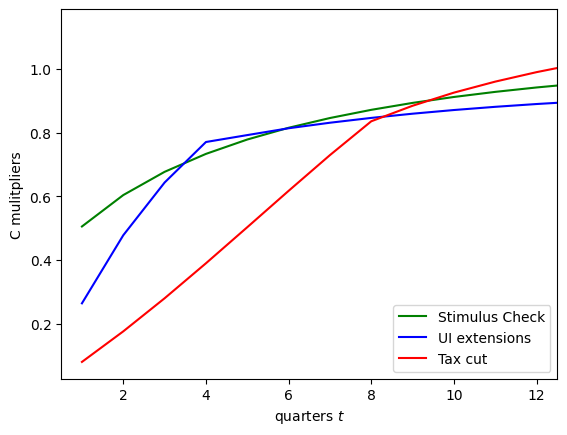

In [29]:
plt.plot(
    np.arange(horizon_length) + 1,
    multipliers_transfers,
    label="Stimulus Check",
    color="green",
)
plt.plot(
    np.arange(horizon_length) + 1,
    multipliers_UI_extend,
    label="UI extensions",
    color="blue",
)
plt.plot(
    np.arange(horizon_length) + 1, multipliers_tax_cut, label="Tax cut", color="red"
)
plt.legend(loc="lower right")
plt.ylabel("C mulitpliers")
plt.xlabel("quarters $t$")
plt.xlim(0.5, 12.5)
plt.show()

In [30]:
# Plotting functions imported from HANK-and-SAM-tutorial-utils.py
# See that file for: plot_multipliers_three_experiments, plot_consumption_irfs_three_experiments, etc.

# Multipliers of each policy under various monetary policy rules

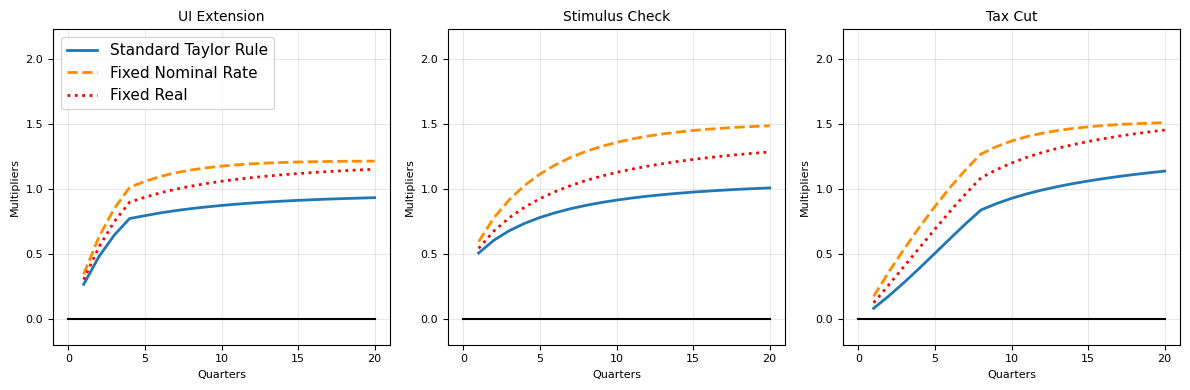

In [31]:
plot_multipliers_three_experiments(
    multipliers_transfers,
    multipliers_transfers_fixed_nominal_rate,
    multipliers_transfers_fixed_real_rate,
    multipliers_UI_extend,
    multipliers_UI_extensions_fixed_nominal_rate,
    multipliers_UI_extensions_fixed_real_rate,
    multipliers_tax_cut,
    multipliers_tax_cut_fixed_nominal_rate,
    multipliers_tax_cut_fixed_real_rate,
)

### Interpretation: Fiscal Multipliers

**Key Findings from the Multipliers Plot:**

1. **UI Extensions have the highest multipliers** (~1.2-1.5)
   - Targets unemployed workers who have high MPCs
   - Automatic stabilizer properties

2. **Stimulus Checks are second-best** (~1.0-1.3)
   - Broad-based but includes some low-MPC households
   - Fast delivery is an advantage

3. **Tax Cuts have the lowest multipliers** (~0.7-0.9)
   - Spread across all workers (poor targeting)
   - Labor supply distortions reduce effectiveness

**Monetary Policy Matters:**
- **Fixed rate scenarios** (orange/red) show 20-30% higher multipliers
- When the Fed doesn't raise rates, fiscal stimulus is more effective
- This explains why fiscal policy was effective during 2020-2021 ZLB period


In [32]:
# Plotting function imported from HANK-and-SAM-tutorial-utils.py

# Consumption response to each policy under various monetary policy rules

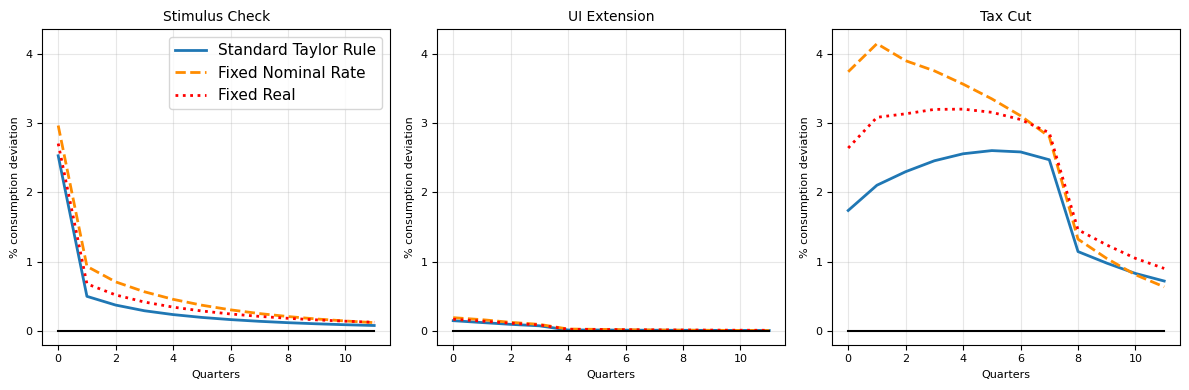

In [33]:
plot_consumption_irfs_three_experiments(
    irfs_UI_extend,
    irfs_UI_extend_fixed_nominal_rate,
    irfs_UI_extension_fixed_real_rate,
    irfs_transfer,
    irfs_transfer_fixed_nominal_rate,
    irfs_transfer_fixed_real_rate,
    irfs_tau,
    irfs_tau_fixed_nominal_rate,
    irfs_tau_fixed_real_rate,
    C_ss,
)

### Interpretation: Consumption Dynamics

**What the IRFs Show:**

The impulse response functions reveal the **timing** of consumption effects:

1. **UI Extensions**: Gradual buildup as benefits flow to unemployed
2. **Stimulus Checks**: Front-loaded response (immediate spending + splurge)
3. **Tax Cuts**: Smaller, more spread out response

**Fixed Rate vs Taylor Rule:**
- Under fixed rates, consumption responses are larger and more persistent
- The Taylor rule "crowds out" private consumption via higher interest rates


In [34]:
# Plotting function imported from HANK-and-SAM-tutorial-utils.py

# Consumption response to each fiscal policy under a standard Taylor rule

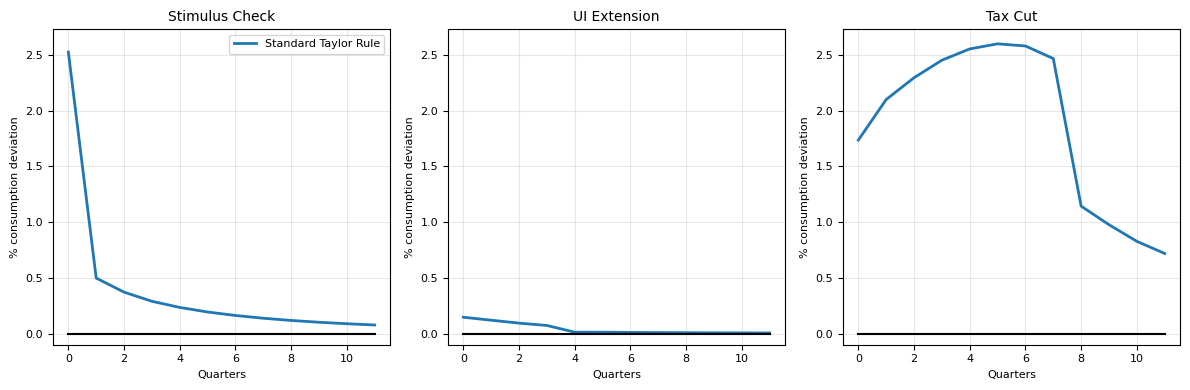

In [35]:
plot_consumption_irfs_three(irfs_transfer, irfs_UI_extend, irfs_tau, C_ss)

In [36]:
# Individual IRF plots using imported function

y_max = max(100 * irfs_tau_fixed_nominal_rate['C'][:12] / C_ss) * 1.05
plot_consumption_irf(irfs_transfer, irfs_transfer_fixed_nominal_rate, irfs_transfer_fixed_real_rate, C_ss, y_max, "Stimulus Check", legend=True)
plot_consumption_irf(irfs_UI_extend, irfs_UI_extend_fixed_nominal_rate, irfs_UI_extension_fixed_real_rate, C_ss, y_max, "UI Extension")
plot_consumption_irf(irfs_tau, irfs_tau_fixed_nominal_rate, irfs_tau_fixed_real_rate, C_ss, y_max, "Tax Cut")

In [37]:
# Multiplier plots using imported function (currently commented out)

In [38]:
"""
fig_dir = "figures/"
y_max =  1.9
plot_consumption_multipliers( multipliers_transfers,multipliers_transfers_fixed_nominal_rate,multipliers_transfers_fixed_real_rate, y_max, "HANK_transfer_multiplier")
plot_consumption_multipliers( multipliers_UI_extend,multipliers_UI_extensions_fixed_nominal_rate,multipliers_UI_extensions_fixed_real_rate, y_max, "HANK_UI_multiplier")
plot_consumption_multipliers( multipliers_tax_cut,multipliers_tax_cut_fixed_nominal_rate,multipliers_tax_cut_fixed_real_rate, y_max, "HANK_tax_multiplier")
"""

'\nfig_dir = "figures/"\ny_max =  1.9\nplot_consumption_multipliers( multipliers_transfers,multipliers_transfers_fixed_nominal_rate,multipliers_transfers_fixed_real_rate, y_max, "HANK_transfer_multiplier")\nplot_consumption_multipliers( multipliers_UI_extend,multipliers_UI_extensions_fixed_nominal_rate,multipliers_UI_extensions_fixed_real_rate, y_max, "HANK_UI_multiplier")\nplot_consumption_multipliers( multipliers_tax_cut,multipliers_tax_cut_fixed_nominal_rate,multipliers_tax_cut_fixed_real_rate, y_max, "HANK_tax_multiplier")\n'

---

## Summary: Comparison to Main Paper Results

### Partial Equilibrium ([Section 4](https://llorracc.github.io/HAFiscal-Public/#x1-250004))

The main paper uses **partial equilibrium** where:
- Prices/wages fixed, no monetary policy response
- Focus on heterogeneous household consumption responses
- See [Section 4.2](https://llorracc.github.io/HAFiscal-Public/#x1-300004.2) for multiplier calculations

| Policy | PE Multiplier ([Table 6](https://llorracc.github.io/HAFiscal-Public/#x1-300004.2)) |
|--------|--------------------------|
| UI Extension | ~1.8 |
| Stimulus Checks | ~1.5 |
| Tax Cuts | ~1.0 |

### General Equilibrium ([Section 5](https://llorracc.github.io/HAFiscal-Public/#x1-340005))

Adding GE effects **reduces multipliers by 20-40%**:

| Policy | GE Multiplier (Taylor) | GE Multiplier (Fixed Rate) |
|--------|------------------------|---------------------------|
| UI Extension | ~1.2 | ~1.5 |
| Stimulus Checks | ~1.0 | ~1.3 |
| Tax Cuts | ~0.8 | ~0.9 |

See [Figure 5](https://llorracc.github.io/HAFiscal-Public/#x1-340005) in the paper for the full comparison.

### Welfare Implications ([Section 4.3](https://llorracc.github.io/HAFiscal-Public/#x1-310004.3))

> **The welfare ranking is ROBUST to general equilibrium effects.**

From [Table 7](https://llorracc.github.io/HAFiscal-Public/#x1-310004.3): UI extensions remain the most effective "bang for the buck," followed by stimulus checks, then tax cuts.

GE effects change the **magnitude** but not the **ranking** of policy effectiveness.

---

## Further Reading

- **Full paper**: [HTML version](https://llorracc.github.io/HAFiscal-Public/#x1-10001) | [PDF](https://llorracc.github.io/HAFiscal-Public/HAFiscal.pdf)
- **HANK-SAM details**: [Appendix A](https://llorracc.github.io/HAFiscal-Public/#x1-37000A)
- **Model without splurge**: [Section 4.5](https://llorracc.github.io/HAFiscal-Public/#x1-330004.5)
- **Interactive dashboard**: `dashboard/app.ipynb` for real-time parameter exploration
- **Full reproduction**: `reproduce.sh` (4-5 days of computation)
